In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns  # a useful plotting library on top of matplotlib
from tqdm.auto import tqdm # a nice progress bar
from torch.nn import Linear, ReLU, Sequential
import csv
import pandas as pd

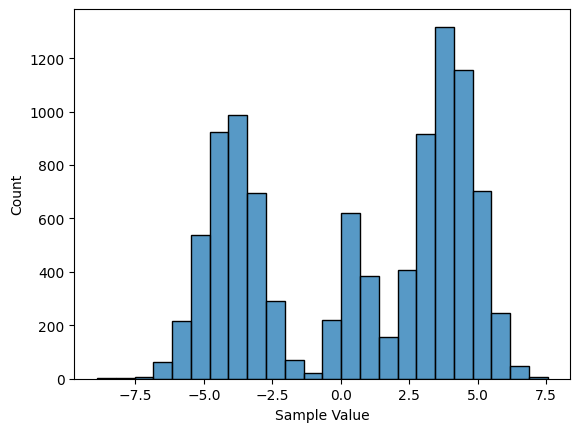

In [16]:
# # This is a simple example of a diffusion model in 1D.


# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1.5, 0.5, 2])),
    torch.distributions.Normal(torch.tensor([-4., 0.5, 4.]), torch.tensor([1., 0.5, 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set
fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
plt.xlabel("Sample Value")
plt.show()

In [3]:
# we will keep these parameters fixed throughout
# these parameters should give you an acceptable result
# but feel free to play with them
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 128
LEARNING_RATE = 0.8e-4
HIDDEN_DIM = 64

In [4]:
# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

g = Sequential(
    Linear(2,HIDDEN_DIM),
    ReLU(),
    Linear(HIDDEN_DIM,HIDDEN_DIM),
    ReLU(),
    Linear(HIDDEN_DIM,1)
)

optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)

In [5]:
alpha = 1-BETA
alpha_bar = alpha.repeat(TIME_STEPS)
alpha_bar = torch.stack([alpha_bar[i]**(i+1) for i in range(TIME_STEPS)])

print(alpha_bar.shape)

torch.Size([250])


In [ ]:
epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar

# Logging the loss
log_file = open('forward_noising_log.csv', 'w', newline='')
writer = csv.writer(log_file)
writer.writerow(['epoch', 'train_loss', 'val_loss'])


for e in epochs: # loop over epochs
    g.train()
    # loop through batches of the dataset, reshuffling it each epoch
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]
    train_losses = []
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        # sample a batch of data
        x0 = shuffled_dataset[i:i + BATCH_SIZE]

        # here, implement algorithm 1 of the DDPM paper (https://arxiv.org/abs/2006.11239)
        t = torch.randint(0,TIME_STEPS, (x0.shape[0],))
        epsilon = torch.randn(x0.shape[0])

        ab = alpha_bar[t]
        xt = ab.sqrt() * x0 + (1 - ab).sqrt() * epsilon

        inp = torch.stack([xt, t.float()], dim =1)
        epsilon_pred = g(inp).squeeze(1)

        loss = torch.nn.functional.mse_loss(epsilon_pred, epsilon)
        train_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_train_loss = sum(train_losses) / len(train_losses)

    # compute the loss on the validation set
    g.eval()
    with torch.no_grad():
        x0 = dataset_validation
        t = torch.randint(0,TIME_STEPS, (x0.shape[0],))
        epsilon = torch.randn(x0.shape[0])

        ab = alpha_bar[t]
        xt = ab.sqrt() * x0 + (1 - ab).sqrt() * epsilon

        inp = torch.stack([xt, t.float()], dim =1)
        epsilon_pred = g(inp).squeeze(1)

        val_loss = torch.nn.functional.mse_loss(epsilon_pred, epsilon)

        writer.writerow([e, mean_train_loss, val_loss.item()])
        log_file.flush()

        epochs.set_postfix(train_loss = loss.item(), val_loss = val_loss.item())

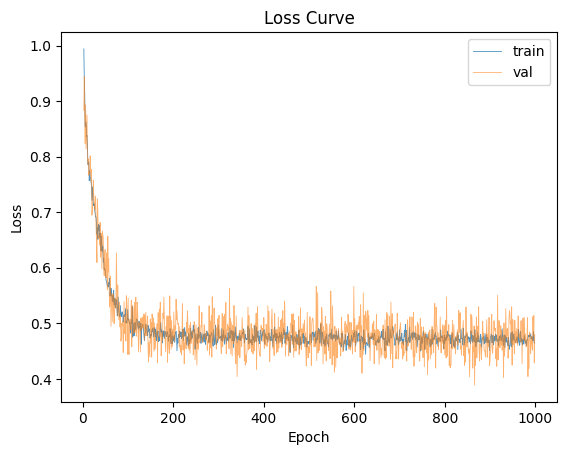

In [7]:
log = pd.read_csv('forward_noising_log.csv')


fig, ax = plt.subplots()
ax.plot(log['epoch'][1:], log['train_loss'][1:], label='train', alpha = 0.8, linewidth = 0.6)
ax.plot(log['epoch'][1:], log['val_loss'][1:], label='val', alpha = 0.6, linewidth = 0.6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')
ax.legend()
plt.show()

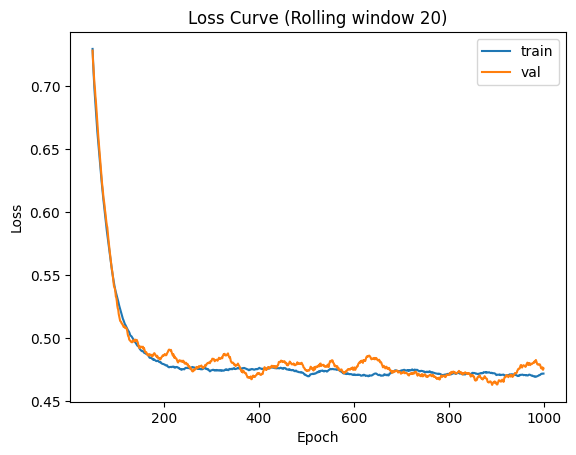

In [15]:
window = 50
fig, ax = plt.subplots()
ax.plot(log['epoch'][1:], log['train_loss'][1:].rolling(window).mean(), label='train')
ax.plot(log['epoch'][1:], log['val_loss'][1:].rolling(window).mean(), label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve (Rolling window 20)')
ax.legend()
plt.show()

In [9]:
def sample_reverse(g, count):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    g : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    Returns
    -------
    x : torch.Tensor
        The final sample from the model
    """
    g.eval()
    x = torch.randn(count)

    for t_val in reversed(range(TIME_STEPS)):
        t = torch.full((count,), t_val, dtype=torch.float)
        inp = torch.stack([x,t], dim = 1)

        with torch.no_grad():
            epsilon_pred = g(inp).squeeze(1)

        ab = alpha_bar[t_val]
        mean = alpha.rsqrt() * (x - (1 - alpha) / (1 - ab).sqrt() * epsilon_pred)

        if t_val > 0:
            z = torch.randn(count)
            x = mean + BETA.sqrt() * z
        else:
            x = mean

    return x

Text(0, 0.5, 'Sample count')

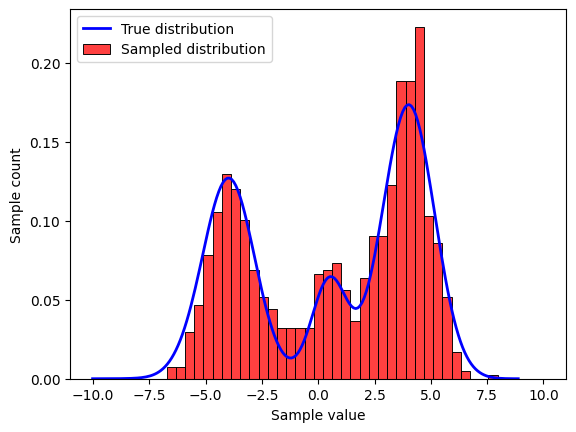

In [10]:
samples = sample_reverse(g, 1000)
samples = samples.detach().numpy()

# plot the samples
fig, ax = plt.subplots(1, 1)
bins = np.linspace(-10, 10, 50)
sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density')
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')